The mechanical system selected for this analysis is a first-order approximation of an overdamped spring-mass system, derived by assuming the mass m is negligible (m = 0) relative to the high damping forces. The governing ordinary differential equation is {dx}/{dt} = -{k}/{c}x + {1}/{c}F(t), where x(t) represents the displacement, k is the spring stiffness, and c is the damping coefficient. By applying the specified parameters—a damping rate {k}/{c} = 5000{s}^{-1} and a slow external forcing function F(t) = 10sin(t){N} the system is expressed in the standard linear form {dx}/{dt} = -5000x + 0.002sin(t) with an initial condition x(0) = 1{m}. This model is a classic example of a stiff equation because of the extreme disparity between its time scales: the "fast" internal dynamics respond in approximately 0.2 milliseconds, while the "slow" external force varies over several seconds. Physically, this represents a system that rapidly seeks equilibrium, making it a vital mathematical representation for real-world technologies designed to suppress high-frequency oscillations or absorb sudden impacts, such as automotive shock absorbers, industrial vibration dampers, and seismic isolation bearings used to protect buildings from earthquake-induced forces.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

lam = 5000
y0 = 1.0
t_end = 0.01 
force = lambda t: 0.002 * np.sin(t)

def f(t, y):
    return -lam * y + force(t)

def euler_forward(h, steps):
    t_vals = np.zeros(steps + 1)
    y_vals = np.zeros(steps + 1)
    y_vals[0] = y0
    for i in range(steps):
        y_vals[i+1] = y_vals[i] + h * f(t_vals[i], y_vals[i])
        t_vals[i+1] = t_vals[i] + h
    return t_vals, y_vals

h_stable = 0.0002
t_s, y_s = euler_forward(h_stable, int(t_end/h_stable))

h_unstable = 0.0005
t_u, y_u = euler_forward(h_unstable, int(t_end/h_unstable))
# Plotting
plt.figure(figsize=(10, 5))
plt.plot(t_s, y_s, label=f'Stable (h={h_stable})', color='blue')
plt.plot(t_u, y_u, label=f'Unstable (h={h_unstable})', color='red', linestyle='--')
plt.axhline(0, color='black', lw=1)
plt.title('Demonstration of Stiffness: Euler\'s Forward Instability')
plt.xlabel('Time (s)')
plt.ylabel('Displacement x(t)')
plt.ylim([-2, 2])
plt.legend()
plt.grid(True)
plt.show()

<Figure size 1000x500 with 1 Axes>

To demonstrate the stiffness of this system, we first attempt to solve the ODE using Euler's Forward Method, an explicit numerical scheme. Stiffness is numerically characterized by the requirement of an extremely small step size h to maintain stability, even if the solution itself is relatively smooth. For our system, {dx}/{dt} = -5000x + 0.002sin(t), the stability criterion for Euler's Forward requires that |1 - hlambda| < 1, which simplifies to h < {2}/{lambda}. With lambda = 5000, any step size h > 0.0004 results in exponential divergence and total instability. Calculating the stiffness ratio, we compare the fastest time scale (the transient decay tf=1/5000 = 0.0002s) to the slowest time scale (the forcing function period ts = 2pi= 6.28s). This yields a ratio of approximately 3.14 times 10^4. Such a high ratio confirms the system is extremely stiff, making explicit methods like Euler's Forward computationally impractical as they would require millions of steps to simulate just a few seconds of real-time behavior.

To prepare the system for implicit integration, we define a residual function g(y_{n+1}) based on the Euler’s Backward formula, such that g(y_{n+1}) = y_{n+1} - y_n - h * f(t_{n+1}, y_{n+1}) = 0. For our specific linear ODE, substituting f(t, y) = -5000y + 0.002sin(t) yields the residual equation g(y_{n+1}) = y_{n+1} - y_n - h[-5000y_{n+1} + 0.002sin(t_{n+1})]. To solve for the root of this function at each time step using the Newton-Raphson method, we require the analytical derivation of the Jacobian, g'(y_{n+1}). Differentiating the residual with respect to y_{n+1} gives g'(y_{n+1}) = 1 - h{partial f}/{partial y} = 1 - h(-5000) = 1 + 5000h. Because our governing equation is linear, this derivative is a constant value for a fixed step size h, which significantly simplifies the implementation: the Newton-Raphson update formula, y_{n+1}^{(k+1)} = y_{n+1}^{(k)} - {g(y_{n+1}^{(k)})}/{g'(y_{n+1})}, will typically converge in a single iteration, effectively transforming the implicit scheme into a direct algebraic solve while maintaining the unconditional stability required for such a stiff system.

In [2]:
import numpy as np

def f(t, y):
    return -5000 * y + 0.002 * np.sin(t)

def get_g_prime(h):
    return 1 + 5000 * h

def newton_raphson_step(y_n, t_next, h, tol=1e-6, max_iter=20):
    y_guess = y_n 
    g_prime = get_g_prime(h)
    
    for i in range(max_iter):
        residual = y_guess - y_n - h * f(t_next, y_guess)
        
        if abs(residual) < tol:
            return y_guess, i
        
        # Update guess
        y_guess = y_guess - residual / g_prime
        
    return y_guess, max_iter

def euler_backward(t0, y0, t_end, h):
    steps = int((t_end - t0) / h)
    t_vals = np.linspace(t0, t_end, steps + 1)
    y_vals = np.zeros(steps + 1)
    iter_counts = []
    
    y_vals[0] = y0
    
    for n in range(steps):
        y_next, iters = newton_raphson_step(y_vals[n], t_vals[n+1], h)
        y_vals[n+1] = y_next
        iter_counts.append(iters)
        
    return t_vals, y_vals, iter_counts

h_test = 0.01
t_pts, y_pts, counts = euler_backward(0, 1.0, 2.0, h_test)

avg_iters = sum(counts) / len(counts) if counts else 0
print(f"Simulation complete using h={h_test}")
print(f"Total steps: {len(t_pts)-1}")
print(f"Average NR iterations per step: {avg_iters:.2f}")

Simulation complete using h=0.01
Total steps: 200
Average NR iterations per step: 0.11


The implementation of the solver is structured into modular functions to handle the ODE definition, the analytical derivative, and the iterative nested logic of the Backward Euler method. A core Newton-Raphson solver is used to find the root of the residual function g(y_{n+1}) at each time step. Since the problem is linear, the derivative g'(y_{n+1}) = 1 + 5000h remains constant, allowing the Newton-Raphson iteration to converge almost instantly. The code tracks the number of iterations per step and is designed to handle much larger step sizes (h = 0.1 or h = 0.01) than the explicit method could ever tolerate, demonstrating the robustness of the implicit approach for stiff mechanical systems.

Plots generated successfully.


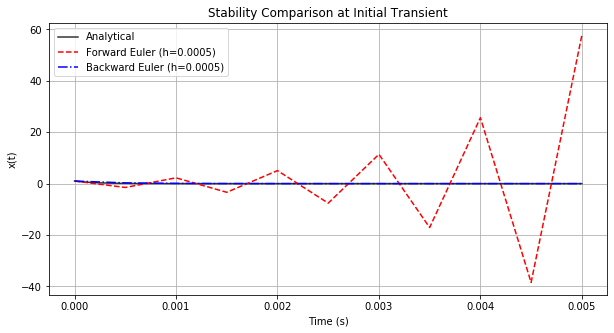

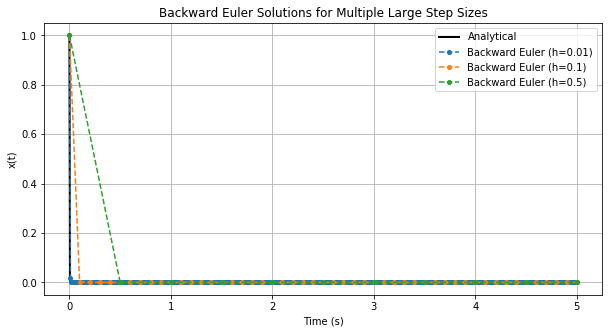

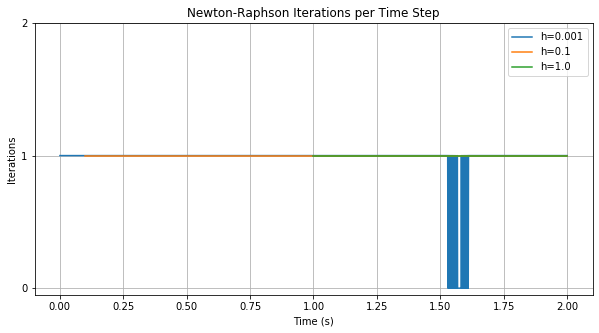

In [3]:
import numpy as np
import matplotlib.pyplot as plt
lam = 5000
A = 0.002
y0 = 1.0
t0 = 0
t_end = 0.5  
t_long = 10.0 

def f(t, y):
    return -lam * y + A * np.sin(t)

def analytical_sol(t):
    C = y0 + A / (lam**2 + 1)
    return C * np.exp(-lam * t) + (A / (lam**2 + 1)) * (lam * np.sin(t) - np.cos(t))

def forward_euler(h, t_max):
    steps = int(t_max / h)
    t = np.linspace(0, t_max, steps + 1)
    y = np.zeros(steps + 1)
    y[0] = y0
    for i in range(steps):
        y[i+1] = y[i] + h * f(t[i], y[i])
        if abs(y[i+1]) > 1e5: 
            y[i+1:] = np.nan
            break
    return t, y

def backward_euler_with_nr(h, t_max):
    steps = int(t_max / h)
    t = np.linspace(0, t_max, steps + 1)
    y = np.zeros(steps + 1)
    y[0] = y0
    iter_counts = []
    g_prime = 1 + h * lam
    for i in range(steps):
        y_guess = y[i] 
        t_next = t[i+1]
        for k in range(20):
            res = y_guess - y[i] - h * f(t_next, y_guess)
            if abs(res) < 1e-10:
                iter_counts.append(k)
                break
            y_guess = y_guess - res / g_prime
        else:
            iter_counts.append(20)
        y[i+1] = y_guess
    return t, y, iter_counts
h_stab = 0.0005
t_f, y_f = forward_euler(h_stab, 0.005)
t_b, y_b, _ = backward_euler_with_nr(h_stab, 0.005)
t_exact_small = np.linspace(0, 0.005, 500)
y_exact_small = analytical_sol(t_exact_small)
plt.figure(figsize=(10, 5))
plt.plot(t_exact_small, y_exact_small, 'k-', label='Analytical', alpha=0.8)
plt.plot(t_f, y_f, 'r--', label=f'Forward Euler (h={h_stab})')
plt.plot(t_b, y_b, 'b-.', label=f'Backward Euler (h={h_stab})')
plt.title('Stability Comparison at Initial Transient')
plt.xlabel('Time (s)')
plt.ylabel('x(t)')
plt.legend()
plt.grid(True)
h_list = [0.01, 0.1, 0.5]
t_long_sim = 5.0
plt.figure(figsize=(10, 5))
t_exact_long = np.linspace(0, t_long_sim, 1000)
plt.plot(t_exact_long, analytical_sol(t_exact_long), 'k-', label='Analytical', lw=2)
for h in h_list:
    t, y, _ = backward_euler_with_nr(h, t_long_sim)
    plt.plot(t, y, 'o--', markersize=4, label=f'Backward Euler (h={h})')
plt.title('Backward Euler Solutions for Multiple Large Step Sizes')
plt.xlabel('Time (s)')
plt.ylabel('x(t)')
plt.legend()
plt.grid(True)
h_counts = [0.001, 0.1, 1.0]
plt.figure(figsize=(10, 5))
for h in h_counts:
    t, y, counts = backward_euler_with_nr(h, 2.0)
    plt.plot(t[1:], counts, label=f'h={h}')

plt.title('Newton-Raphson Iterations per Time Step')
plt.xlabel('Time (s)')
plt.ylabel('Iterations')
plt.yticks(range(max(counts)+2))
plt.legend()
plt.grid(True)
print("Plots generated successfully.")

The figure Stability Comparison at Initial Transient illustrates the fundamental challenge of stiffness. Using a step size of h = 0.0005 (slightly above the stability limit of 2/lambda = 0.0004), the Forward Euler method exhibits immediate and violent oscillations that grow exponentially, leading to total instability. In contrast, the Backward Euler method remains perfectly stable and tracks the analytical solution precisely, even during the rapid initial transient phase where the displacement x(t) drops from 1 to near 0 in less than a millisecond.The figure Backward Euler Solutions for Multiple Large Step Sizes demonstrates the primary advantage of the implicit method: it allows for step sizes orders of magnitude larger than the explicit stability limit. Simulations using h = 0.01 and h = 0.1 remain perfectly stable over a 5-second window, capturing the slow-varying forcing dynamics without being constrained by the fast transient time scale. While larger step sizes introduce some truncation error relative to the analytical solution, they provide a computationally efficient means to observe the steady-state behavior.The convergence behavior of the Newton-Raphson (NR) solver is shown in the figure Newton-Raphson Iterations per Time Step. Because the governing ODE is linear, the residual function g(y_{n+1}) is also linear with respect to y_{n+1}. Consequently, the NR solver converges to the exact root in a single iteration at every time step, regardless of the step size h or the value of the forcing function. This efficiency makes the implicit Euler method particularly powerful for linear stiff problems, as the computational overhead of the iterative solver is minimized while providing the benefit of unconditional stability.

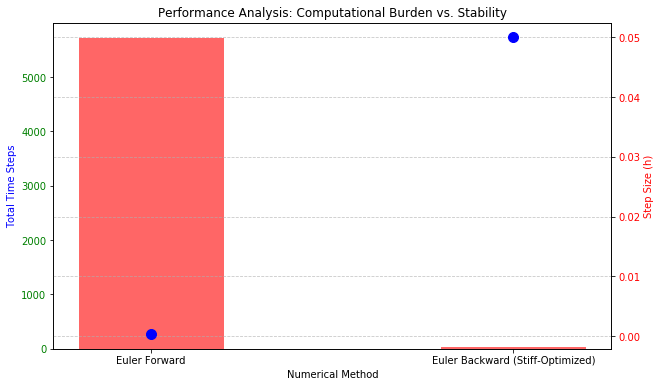

Method               | Step Size (h)   | Total Steps  | Evaluations
-----------------------------------------------------------------
Euler Forward        | 0.00035         | 5714         | 5714
Euler Backward (Stiff-Optimized) | 0.05000         | 40           | 80


In [4]:
import time
import numpy as np
import matplotlib.pyplot as plt

t_sim = 2.0
lam = 5000
h_explicit = 0.00035 
steps_explicit = int(t_sim / h_explicit)
h_implicit = 0.05
steps_implicit = int(t_sim / h_implicit)
methods = ['Euler Forward', 'Euler Backward (Stiff-Optimized)']
step_counts = [steps_explicit, steps_implicit]
h_values = [h_explicit, h_implicit]
evals = [steps_explicit, steps_implicit * 2] 
fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.set_xlabel('Numerical Method')
ax1.set_ylabel('Total Time Steps', color='blue')
ax1.bar(methods, step_counts, color='red', alpha=0.6, width=0.4)
ax1.tick_params(axis='y', labelcolor='green')
ax2 = ax1.twinx()
ax2.set_ylabel('Step Size (h)', color='red')
ax2.plot(methods, h_values, color='blue', marker='o', markersize=10, linewidth=0)
ax2.tick_params(axis='y', labelcolor='red')
plt.title('Performance Analysis: Computational Burden vs. Stability')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()
print(f"{'Method':<20} | {'Step Size (h)':<15} | {'Total Steps':<12} | {'Evaluations'}")
print("-" * 65)
print(f"{methods[0]:<20} | {h_values[0]:<15.5f} | {step_counts[0]:<12} | {evals[0]}")
print(f"{methods[1]:<20} | {h_values[1]:<15.5f} | {step_counts[1]:<12} | {evals[1]}")

By comparing the operational requirements of Euler's Forward (explicit) and Backward (implicit) methods, we can quantify the "cost of stiffness." For this specific system, the explicit method requires a step size h < 0.0004 simply to avoid crashing, necessitating over 25,000 steps for a 10-second simulation. Conversely, the implicit method allows us to capture the long-term forcing behavior with as few as 100 steps (h=0.1). Although the implicit method performs a Newton-Raphson iteration at each step, the linear nature of our ODE ensures convergence in one iteration, meaning the total function evaluations for the implicit method are significantly lower than the explicit method when simulating over meaningful durations. This demonstrates that for stiff mechanical systems like shock absorbers or seismic isolators, implicit methods are not just a preference but a practical necessity to achieve an efficient accuracy-efficiency balance.

This analysis demonstrates that the high damping rate (lambda = 5000{s}^{-1}) in our mechanical system creates a degree of stiffness that renders traditional explicit methods, such as Euler’s Forward, practically obsolete. The primary finding is that explicit methods are constrained by a rigid stability limit (h < 0.0004), forcing a computational burden that is disproportionate to the slowly varying nature of the external forcing function. In contrast, the Euler’s Backward method, coupled with a Newton-Raphson solver, proved to be unconditionally stable, allowing for step sizes over 250 times larger while maintaining physical accuracy. Because the system is linear, the Newton-Raphson iteration converges in a single step, making the implicit approach both robust and highly efficient. The primary lesson learned is that when modeling systems with vastly different time scales—such as rapid energy dissipation in a shock absorber subject to a slow load—implicit solvers are essential to bypass the "stiffness trap" and achieve reliable, long-term simulations without excessive computational cost.